# Header: Measuring vertical electric field (version 1)

Want to understand how electric field looks and can be measured with capacitively coupled receivers

RQs:
- how does the source field look for a uniform halfspace?
- how does the response look to a small anomaly, in Ex, Ey and Ez component?
- what is the effect of frequency on this response?
- what is the impact of the resistivity contrast of the anomaly (positive/negative)?
- what is the effect of source length?
- what is the effect of receiver length?
- how do responses change for a capacitively coupled receiver?

# Code

In [1]:
import emg3d
import empymod
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from Emg3d_extra_grid_functions import * #See note in next cell

plt.style.use('bmh')

# Comment this out on Google Colab
#%matplotlib widget

## Functions

In [2]:
def manual_yz_slice_3x(titles, efield1, efield2, efield3, y_extent=300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-8, vmax = 1e-4):

    fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

    ax1_plot = ax1.imshow(np.abs(efield1), extent = [0, size_y, 0, size_z], norm='log', vmin = vmin, vmax = vmax)
    ax1.set_title(titles[0])
    ax1.set_xlabel('y (m)')
    ax1.set_ylabel('z (m)')
    plt.colorbar(ax1_plot, location='bottom')
    ax1.set_xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    ax1.set_yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    ax1.grid(False)
    
    ax2_plot = ax2.imshow(np.abs(efield2), extent = [0, size_y, 0, size_z], norm='log', vmin = vmin, vmax = vmax)
    ax2.set_title(titles[1])
    ax2.set_xlabel('y (m)')
    ax2.set_ylabel('z (m)')
    plt.colorbar(ax2_plot, location='bottom')
    ax2.set_xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    ax2.set_yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    ax2.grid(False)
    
    ax3_plot = ax3.imshow(np.abs(efield3), extent = [0, size_y, 0, size_z], norm='log', vmin = vmin, vmax = vmax)
    ax3.set_title(titles[2])
    ax3.set_xlabel('y (m)')
    ax3.set_ylabel('z (m)')
    plt.colorbar(ax3_plot, location='bottom')
    ax3.set_xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    ax3.set_yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    ax3.grid(False)

In [161]:
def manual_xyz_slice_9x(title, efield1, efield2, efield3, ix = 0, iy = 0, iz = 0, xmin=-300, xmax=300, ymin=-300, ymax=300, zmin=-250, zmax=0, vmin = 1e-8, vmax = 1e-4):

    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3,3, figsize=(15,15), tight_layout=True)
    fig.suptitle(title)
    axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]
    efields = [efield1, efield2, efield3]

    sizexy = 6.4
    sizez = 4.8
    
    for i in np.arange(len(efields)):
        ax_a = axes[i*3]
        ax_b = axes[i*3+1]
        ax_c = axes[i*3+2]
        fielda, fieldb, fieldc = np.abs(np.transpose(efields[i][ix,:,:])), np.abs(np.transpose(efields[i][:,iy,:])), np.abs(np.transpose(efields[i][:,:,iz]))
        plot_a = ax_a.imshow(fielda, extent = [0, sizexy, 0, sizez], norm='log', vmin = vmin, vmax = vmax)
        #ax_a.contour(fielda, [np.max(fielda)/np.e], colors='pink', origin = 'upper', extent = [0, sizexy, 0, sizez])
        plot_b = ax_b.imshow(fieldb, extent = [0, sizexy, 0, sizez], norm='log', vmin = vmin, vmax = vmax)
        #ax_b.contour(fieldb, [np.max(fieldb)/np.e], colors='pink', origin = 'upper', extent = [0, sizexy, 0, sizez])
        plot_c = ax_c.imshow(fieldc, extent = [0, sizexy, 0, sizexy], norm='log', vmin = vmin, vmax = vmax)
        #ax_c.contour(fieldc, [np.max(fieldc)/np.e], colors='pink', origin = 'lower', extent = [0, sizexy, 0, sizez])
        for ax in [ax_a, ax_b, ax_c]:
            ax.set_title('Field '+str(i+1)+' (V/m)')
            ax.grid(False)
        for ax_plot in [plot_a, plot_b, plot_c]:
            plt.colorbar(ax_plot, location='bottom')
        ax_a.set_xticks(np.arange(0, sizexy, sizexy/4), np.arange(ymin, ymax, (ymax-ymin)/4))
        ax_a.set_yticks(np.arange(0, sizez, sizez/4), np.arange(zmin, zmax, (zmax-zmin)/4))
        ax_a.set_xlabel('y (m)')
        ax_a.set_ylabel('z (m)')
        ax_b.set_xticks(np.arange(0, sizexy, sizexy/4), np.arange(xmin, xmax, (xmax-xmin)/4))
        ax_b.set_yticks(np.arange(0, sizez, sizez/4), np.arange(zmin, zmax, (zmax-zmin)/4))
        ax_b.set_xlabel('x (m)')
        ax_b.set_ylabel('z (m)')
        ax_c.set_xticks(np.arange(0, sizexy, sizexy/4), np.arange(xmin, xmax, (xmax-xmin)/4))
        ax_c.set_yticks(np.arange(0, sizexy, sizexy/4), np.arange(ymin, ymax, (ymax-ymin)/4))
        ax_c.set_xlabel('x (m)')
        ax_c.set_ylabel('y (m)')

## Source field for different sources & frequencies

see also: https://empymod.emsig.xyz/en/stable/gallery/fdomain/src_rec_comparison.html

How does the source field look for a uniform halfspace? we simulate x-, y- and z-directed source at the origin, assuming a perfect infinitessimal dipole source

In [165]:
#Specify which component of the receivers and which frequency range we want to test for

component = 'Ez'
frequencies = [10, 1000, 10000]

if component == 'Ez':
    pab = [31, 32, 33]
elif component == 'Ey':
    pab = [21, 22, 23]
elif component == 'Ex':
    pab = [11, 12, 13]

sources = ['x-dir', 'y-dir', 'z-dir']

In [166]:
#Create a 1D subsurface model to test with

# Layer boundaries
depth = [0, 150, 170]

# Layer resistivities in Ohm.m
res_base = np.array([1e8, 35, 35, 35]) # incl. air (lower res, because of 3D modelling)
res_anomaly = np.array([1e8, 35, 13, 35])

In [167]:
#Specify domain in which to compute the EM response (symmetric in x,y)

x = np.arange(-250,260,10)
rx = np.tile(x[:, None], x.size)
ry = rx.transpose()

z = np.arange(0, 260,10)

In [168]:
base_solutions = {}
anom_solutions = {}
diff_solutions = {}

for i in np.arange(len(frequencies)):
    freq = frequencies[i]
    for j in np.arange(len(pab)):
        ab = pab[j]
        source = sources[j]

        solutions = []
        for res in [res_base, res_anomaly]:

            emp_solution = np.zeros((len(rx), len(ry), len(z)), dtype = complex)
            for m in np.arange(len(z)):
                inp = {
                    'src': [0, 0, 0],
                    'rec': [rx.ravel(), ry.ravel(), z[m]],
                    'depth': depth,
                    'res': res,
                    'freqtime': freq,
                    'verb': 0,
                }
                efield = empymod.dipole(ab=ab, **inp).reshape(rx.shape).amp()
                emp_solution[:,:,m] = efield
            solutions.append(emp_solution)
                    
        base_solutions[component+' for source: '+source+' and freq: '+str(freq)+' Hz'] = solutions[0]
        anom_solutions[component+' for source: '+source+' and freq: '+str(freq)+' Hz'] = solutions[1]
        diff_solutions[component+' for source: '+source+' and freq: '+str(freq)+' Hz'] = solutions[1]-solutions[0]

In [169]:
print(list(emp_solutions.keys()))

['Ex for source: x-dir and freq: 10 Hz', 'Ex for source: y-dir and freq: 10 Hz', 'Ex for source: z-dir and freq: 10 Hz', 'Ex for source: x-dir and freq: 1000 Hz', 'Ex for source: y-dir and freq: 1000 Hz', 'Ex for source: z-dir and freq: 1000 Hz', 'Ex for source: x-dir and freq: 10000 Hz', 'Ex for source: y-dir and freq: 10000 Hz', 'Ex for source: z-dir and freq: 10000 Hz']


In [170]:
print(np.shape(emp_solutions[list(emp_solutions.keys())[0]]))

(34, 34, 25)


In [171]:
print(np.shape(rx))
print(ry[0])

(51, 51)
[-250 -240 -230 -220 -210 -200 -190 -180 -170 -160 -150 -140 -130 -120
 -110 -100  -90  -80  -70  -60  -50  -40  -30  -20  -10    0   10   20
   30   40   50   60   70   80   90  100  110  120  130  140  150  160
  170  180  190  200  210  220  230  240  250]


In [188]:
# what to plot

to_plot = 'base'
ifr = 2
print('frequency: '+str(frequencies[ifr])+' Hz')

if to_plot == 'base':
    emp_solution = base_solutions
elif to_plot == 'anom':
    emp_solution = anom_solutions
elif to_plot == 'diff':
    emp_solution = diff_solutions

frequency: 10000 Hz


x plane:  0
y plane:  0
z plane:  0


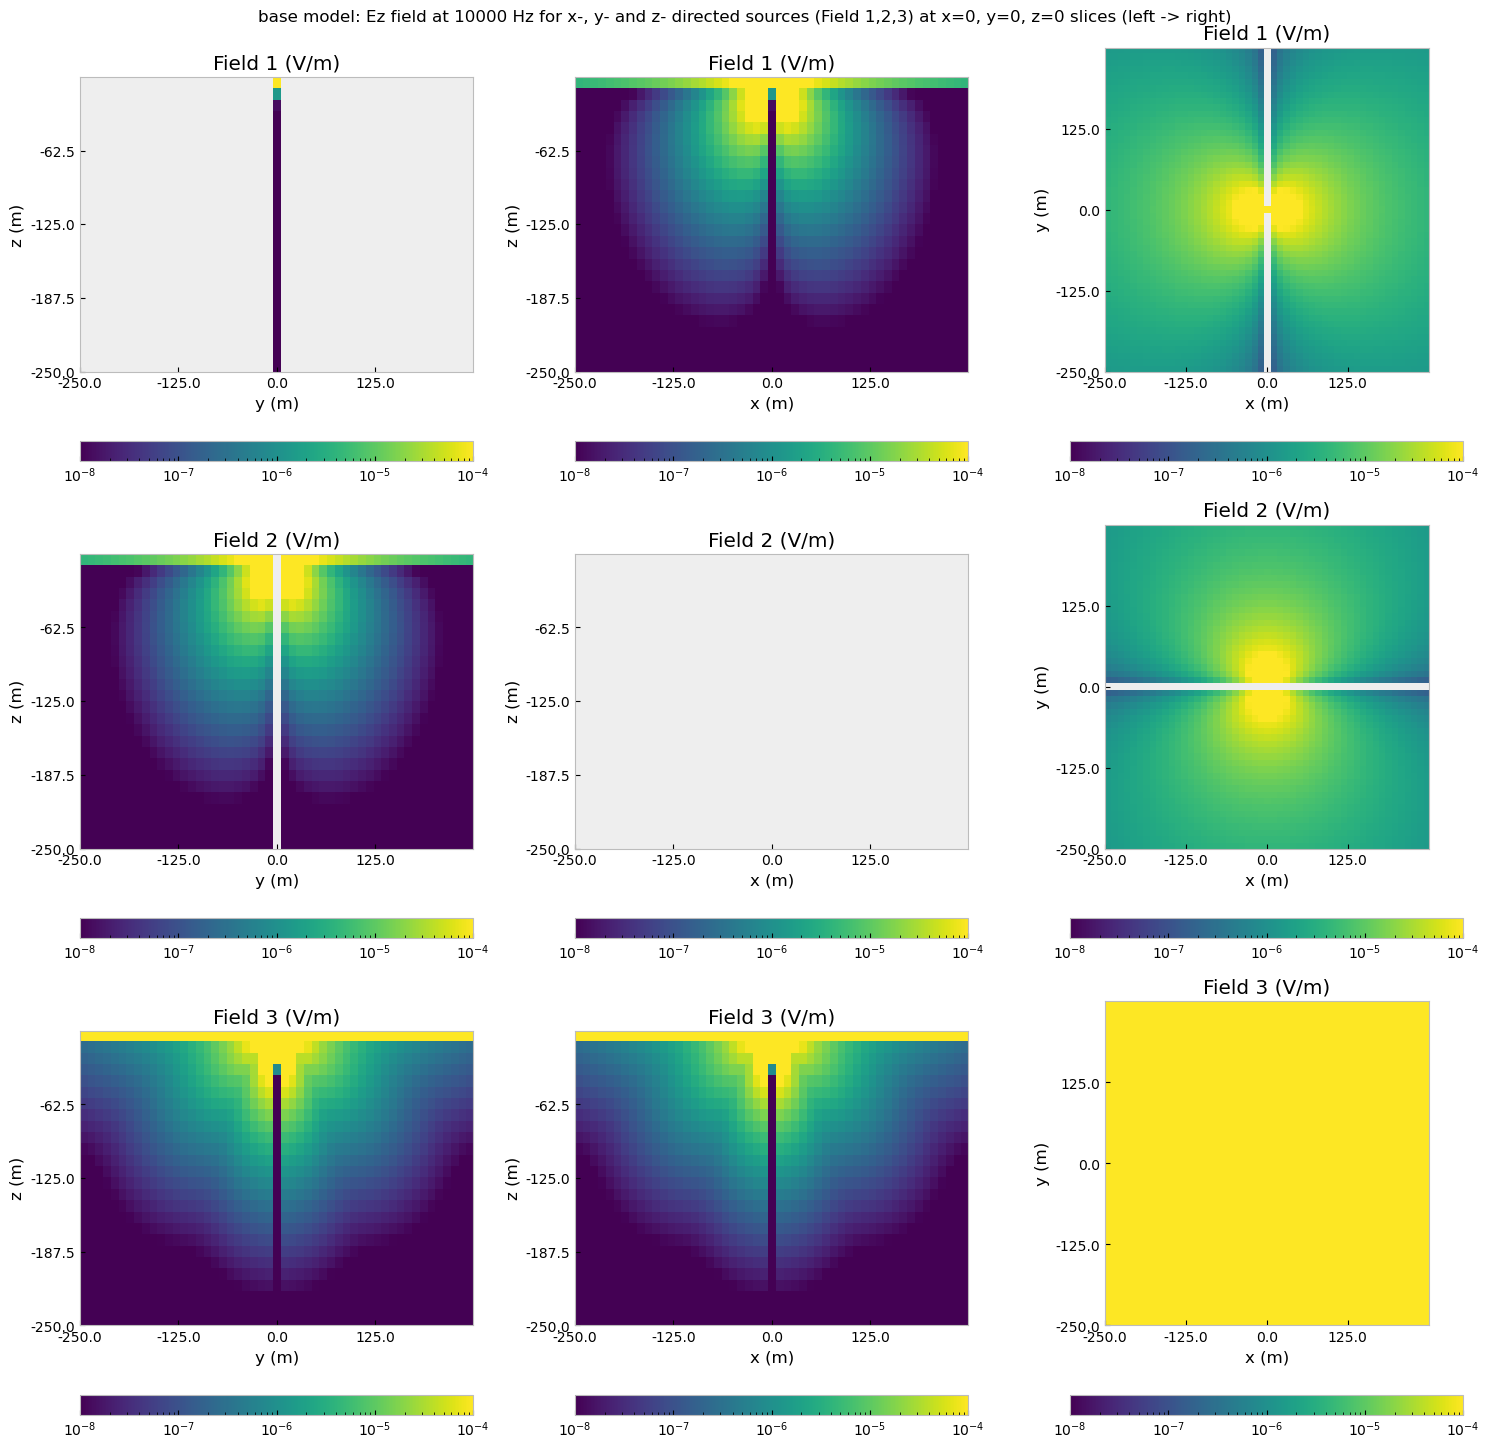

In [189]:
#Plot E fields

keys = list(base_solutions.keys())

ix = 25
iy = 25
iz = 0

print('x plane: ', rx[:,0][ix])
print('y plane: ', ry[0][iy])
print('z plane: ', -z[iz])

efield1 = emp_solution[keys[ifr*3+0]]
efield2 = emp_solution[keys[ifr*3+1]]
efield3 = emp_solution[keys[ifr*3+2]]

title = to_plot+' model: '+component+' field at '+str(frequencies[ifr])+' Hz for x-, y- and z- directed sources (Field 1,2,3) at x='+str(rx[:,0][ix])+', y='+str(ry[0][iy])+', z='+str(z[iz])+' slices (left -> right)'

manual_xyz_slice_9x(title, efield1, efield2, efield3, ix = ix, iy = iy, iz = iz, xmin=rx[:,0][0], xmax=rx[:,0][-1], ymin=ry[0][0], ymax=ry[0][-1], zmin=-z[-1], zmax=z[0], vmin = 1e-8, vmax = 1e-4)

#manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-6, vmax = 1e1)

In [ ]:
efield1 = emp_solutions[keys[ifr*3+0]]
efield2 = emp_solutions[keys[ifr*3+1]]
efield3 = emp_solutions[keys[ifr*3+2]]

manual_plot_Zslice2_3x(efield1, efield2, efield3, ymin = -300, ymax = 300, xmin = -300, xmax = 300, size_y = 6.4, size_x = 6.4, z_slice = 0, vmin = 1e-8, vmax = 1e-4)

## Effect of source length

In [ ]:
# Testing different lengths
lengths_to_test = [10, 25, 50]

# Source frequency
frequencies = [10]

In [ ]:
#Create uniform halfspace model

# Layer boundaries
depth = [0]

# Layer resistivities in Ohm.m for the baseline
resistivities_unif = np.array([1e8, 35]) # base incl. air (lower res, because of 3D modelling)

In [ ]:
#Specify domain in which to compute the response

# Receiver depths, this should be at the z-coordinates of grid cell centers
rcv_z = np.arange(5, 255,10)
# Receiver offsets, this should be at the x,y-coordinates of grid edegs
rcv_x = np.arange(-250,260,15)
rcv_y = np.arange(-250,260,15)

In [ ]:
emp_solutions = {}

freq = frequencies[0]

for i in np.arange(len(lengths_to_test)):
    length = lengths_to_test[i]
    # Source definition
    x_source = [0, 0, 0, 0, 0] # x-directed point dipole on the surface
    y_source = [0, 0, 0, 90.0, 0] # y-directed point dipole on the surface
    z_source = [0, 0, 0, 0, 90.0] # z-directed point dipole on the surface
    sources = [x_source, y_source, z_source]

    
    for j in np.arange(len(sources)):
        source = sources[j]
        
        emp_solution = np.zeros((len(rcv_x), len(rcv_y), len(rcv_z)), dtype = complex)
        for k in np.arange(len(rcv_x)):
            for l in np.arange(len(rcv_y)):
                emp_receivers = [[rcv_x[k]]*len(rcv_z), [rcv_y[l]]*len(rcv_z), -rcv_z, 0, 90.0]
                efield = empymod.bipole(
                        src=source,
                        rec=emp_receivers,
                        depth=depth,
                        res=resistivities_unif,
                        freqtime=freq,
                        verb=0,
                )
                emp_solution[k,l,:] = efield
        emp_solutions['Ez for '+str(freq)+' Hz, source: '+str(source)] = emp_solution

In [ ]:
print(list(emp_solutions.keys()))

In [ ]:
print(np.shape(emp_solutions[list(emp_solutions.keys())[0]]))

In [ ]:
#Plot Ez fields

keys = list(emp_solutions.keys())

ifr = 0

efield1 = emp_solutions[keys[ifr*3]]
print('Field 1: '+keys[ifr*3])
efield2 = emp_solutions[keys[ifr*3+1]]
print('Field 2: '+keys[ifr*3+1])
efield3 = emp_solutions[keys[ifr*3+2]]
print('Field 3: '+keys[ifr*3+2])

manual_xyz_slice_9x(efield1, efield2, efield3, ix = 17, iy = 17, iz = 1, xmin=rcv_x[0], xmax=rcv_x[-1], ymin=rcv_y[0], ymax=rcv_y[-1], zmin=-rcv_z[-1], zmax=rcv_z[0], vmin = 1e-8, vmax = 1e-4)

#manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-6, vmax = 1e1)

We test a 1D layer anomaly at different depths and different contrasts

- depths: 100 m, 200 m, 400 m
- baseline resistivity: 35 Ohmm
- anomaly: 13 Ohmm, 30 Ohmm, 40 Ohmm, 90 Ohmm

In [108]:
anom_depth = [100, 200, 400] #m
thickness = [5, 10, 20] #m
baseline_res = 35 #Ohmm
anom_res = [13, 30, 40, 90] #Ohmm

# Define the baseline model, a uniform halfspace
depth = [0]
resistivities_unif = np.array([1e8, 35])

In [110]:
# define the input that stays the same for all models
inp = {
    'src': y_source,
    'freqtime':1, #Hz
    'htarg': {'pts_per_dec': -1},
    'verb': 1,
}

### Looking at the Ex/Ey/Ez component

quickly edited to check z-directed source

In [299]:
component = 'Ez'

if component == 'Ez':
    rec_az = 0
    rec_dip = 90.0
elif component == 'Ey':
    rec_az = 90.0
    rec_dip = 0
elif component == 'Ey':
    rec_az = 0
    rec_dip = 0

In [300]:
# define the input that stays the same for all models
inp = {
    'src': z_source,
    'freqtime':1, #Hz
    'htarg': {'pts_per_dec': -1},
    'verb': 1,
}

In [301]:
#Specify domain in which to compute the response

# Receiver depths, this should be at the z-coordinates of grid cell centers
rcv_z = np.arange(2.5, 502.5,5)
# Receiver offsets, this should be at the x,y-coordinates of grid edegs
rcv_y = np.arange(-300,310,10)

In [302]:
# Create target models

anom_solutions = {}

for j in np.arange(len(anom_res)):
    for k in np.arange(len(thickness)):
        for i in np.arange(len(anom_depth)):
            depth = [0, -anom_depth[i], -anom_depth[i]-thickness[k]]
            resistivities_target = np.array([1e8, 35, anom_res[j], 35])
    
            anom_solution = np.zeros((len(rcv_y), len(rcv_z)), dtype = complex)
            for l in np.arange(len(rcv_y)):
                receivers = emp_receivers = [[0]*len(rcv_z), [rcv_y[l]]*len(rcv_z), -rcv_z, 0, 90.0]
                efield = empymod.bipole(res=resistivities_target, **inp, depth = depth, rec = receivers)
                anom_solution[l,:] = efield
            anom_solutions[component+': '+str(anom_res[j])+' Ohmm('+str(thickness[k])+'m) anom at z=-'+str(anom_depth[i])+' m '] = anom_solution
            

* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m are set to 0.001 m!
* WARNING :: Offsets < 0.001 m 

Field 1: Ez: 13 Ohmm(5m) anom at z=-100 m 
Field 2: Ez: 13 Ohmm(5m) anom at z=-200 m 
Field 3: Ez: 13 Ohmm(5m) anom at z=-400 m 


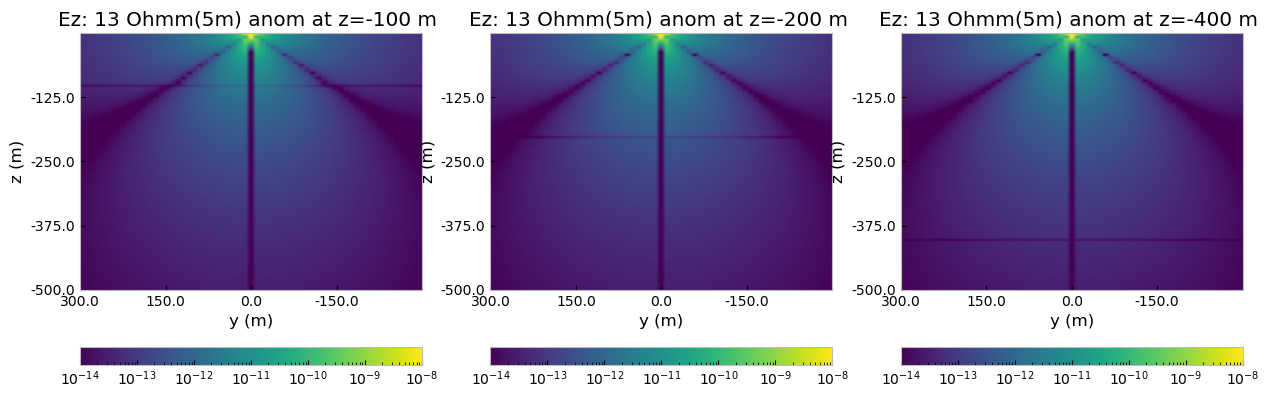

In [306]:
#Plot solutions

keys = list(anom_solutions.keys())
#print(keys)

i = 0

efield1 = np.transpose(anom_solutions[keys[i*3]])
print('Field 1: '+keys[i*3])
efield2 = np.transpose(anom_solutions[keys[i*3+1]])
print('Field 2: '+keys[i*3+1])
efield3 = np.transpose(anom_solutions[keys[i*3+2]])
print('Field 3: '+keys[i*3+2])

titles = [keys[i*3], keys[i*3+1], keys[i*3+2]]

manual_yz_slice_3x(titles, efield1, efield2, efield3, y_extent=-300, zmin=-500, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-14, vmax = 1e-8)

In [242]:
#Sample the field to get the receiver responses at +/- 150 m from the source

len_y = len(rcv_y)
iy = int(len_y*3/4)
print('Ez receivers located at y = '+str(rcv_y[iy]))

anom_responses = []
norm_responses = []
for i in np.arange(len(keys)):
    anom_responses.append(anom_solutions[keys[i]][iy])
    base_response = empymod.bipole(res=resistivities_unif, **inp, depth = [0], rec = [[0]*len(rcv_z), [rcv_y[iy]]*len(rcv_z), -rcv_z, 0, 90.0])
    norm_responses.append(np.array(anom_solutions[keys[i]][iy])/np.array(base_response))

Ez receivers located at y = 150


In [216]:
labels = []
for i in np.arange(len(keys)):
    label = ''.join(list(str(keys[i])[4:16]))
    #print(label)
    labels.append(label)

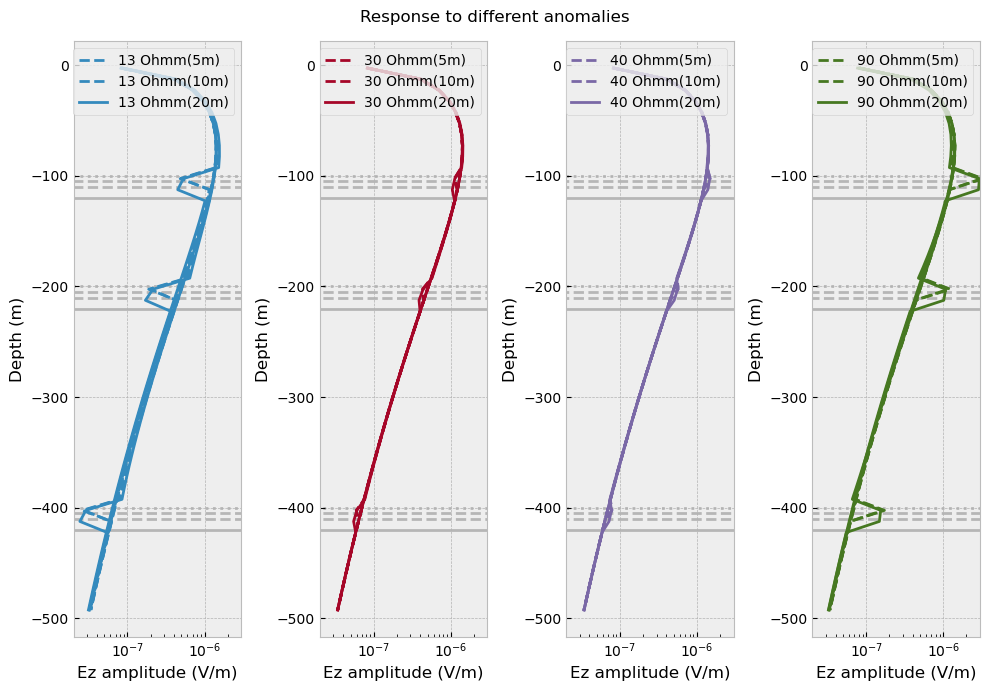

In [241]:
# Plot it
fig3, (ax31, ax32, ax33, ax34) = plt.subplots(1, 4, figsize=(10, 7), tight_layout=True)

fig3.suptitle("Response to different anomalies")
axes = [ax31, ax32, ax33, ax34]
for i in np.arange(len(anom_res)):
    ax = axes[i]
    index = int(i*len(anom_depth)*len(thickness)) #This allows plotting the different depths in the same color etc.
    lss = ['--', '--', '-']
    for k in np.arange(len(thickness)):
        ax.plot(np.abs(anom_responses[index+k*len(anom_depth)]), -rcv_z, 'C'+str(i), ls = lss[k], label=labels[index+k*len(anom_depth)])
        ax.plot(np.abs(anom_responses[index+1+k*len(anom_depth)]), -rcv_z, 'C'+str(i), ls = lss[k])
        ax.plot(np.abs(anom_responses[index+2+k*len(anom_depth)]), -rcv_z, 'C'+str(i), ls = lss[k])
    ax.set_xscale('log')
    ax.set_xlim([2e-8, 3e-6])
    ax.set_xlabel('Ez amplitude (V/m)')
    ax.set_ylabel('Depth (m)')
    for j in np.arange(len(anom_depth)):
        ax.hlines(-anom_depth[j], 0, 1, color=('gray', 0.5), ls=':', zorder=-1)
        ax.hlines(-anom_depth[j]-thickness[0], 0, 1, color=('gray', 0.5), ls='--', zorder=-1)
        ax.hlines(-anom_depth[j]-thickness[1], 0, 1, color=('gray', 0.5), ls='--', zorder=-1)
        ax.hlines(-anom_depth[j]-thickness[2], 0, 1, color=('gray', 0.5), ls='-', zorder=-1)
    ax.legend()

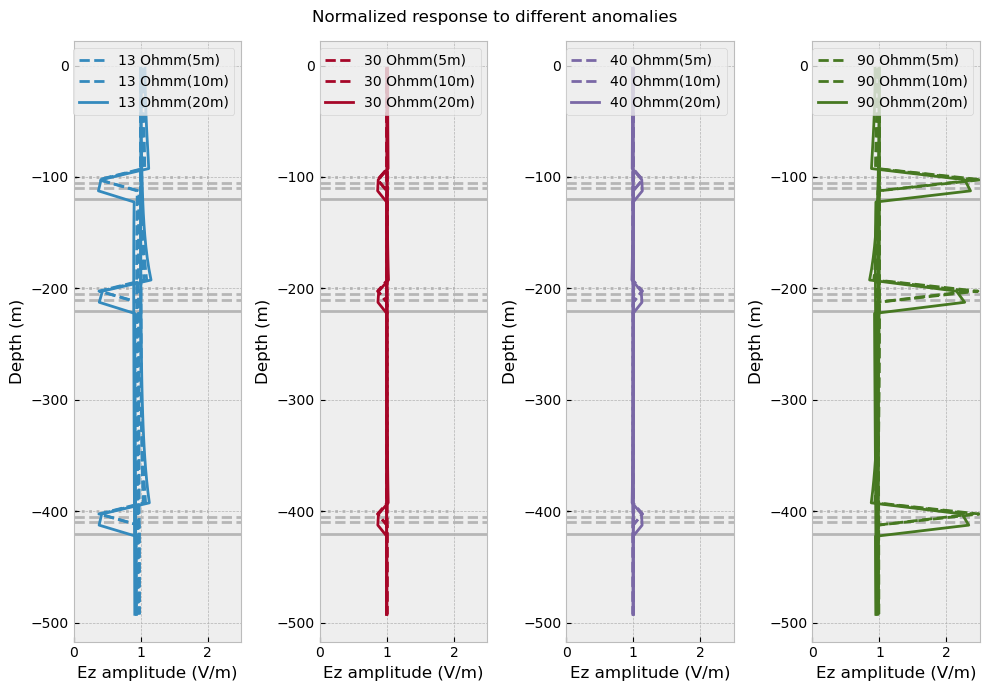

In [249]:
fig3, (ax31, ax32, ax33, ax34) = plt.subplots(1, 4, figsize=(10, 7), tight_layout=True)

fig3.suptitle("Normalized response to different anomalies")
axes = [ax31, ax32, ax33, ax34]
for i in np.arange(len(anom_res)):
    ax = axes[i]
    index = int(i*len(anom_depth)*len(thickness)) #This allows plotting the different depths in the same color etc.
    lss = ['--', '--', '-']
    for k in np.arange(len(thickness)):
        ax.plot(np.abs(norm_responses[index+k*len(anom_depth)]), -rcv_z, 'C'+str(i), ls = lss[k], label=labels[index+k*len(anom_depth)])
        ax.plot(np.abs(norm_responses[index+1+k*len(anom_depth)]), -rcv_z, 'C'+str(i), ls = lss[k])
        ax.plot(np.abs(norm_responses[index+2+k*len(anom_depth)]), -rcv_z, 'C'+str(i), ls = lss[k])
    #ax.set_xscale('log')
    ax.set_xlim([0.0, 2.5])
    ax.set_xlabel('Ez amplitude (V/m)')
    ax.set_ylabel('Depth (m)')
    for j in np.arange(len(anom_depth)):
        ax.hlines(-anom_depth[j], 0, 2, color=('gray', 0.5), ls=':', zorder=-1)
        ax.hlines(-anom_depth[j]-thickness[0], 0, 2.5, color=('gray', 0.5), ls='--', zorder=-1)
        ax.hlines(-anom_depth[j]-thickness[1], 0, 2.5, color=('gray', 0.5), ls='--', zorder=-1)
        ax.hlines(-anom_depth[j]-thickness[2], 0, 2.5, color=('gray', 0.5), ls='-', zorder=-1)
    ax.legend()

## Ez/Ex response to anomaly

We test a 1D layer anomaly:

- depth: 150 m
- thickness: 20 m
- anomaly resistivity: 20 Ohmm
- baseline resistivity: 35 Ohmm

In [85]:
#First we specify whether we want to test for Ez or Ex

component = 'Ez'

if component == 'Ez':
    rec_az = 0
    rec_dip = 90.0
elif component == 'Ey':
    rec_az = 90.0
    rec_dip = 0
elif component == 'Ey':
    rec_az = 0
    rec_dip = 0

In [86]:
# Sources
x_source = [0, 0, 0, 0, 0] # x-directed point dipole on the surface
y_source = [0, 0, 0, 90.0, 0] # y-directed point dipole on the surface
z_source = [0, 0, 0, 0, 90.0] # z-directed point dipole on the surface
sources = [x_source, y_source, z_source]

# Source frequency
frequencies = [10, 1000, 10000]

In [90]:
# Define the anomaly model

baseline_res = 35 #Ohmm
anom_res = 20 #Ohmm

depth = [0, 150, 170]
res_target = np.array([1e8, baseline_res, anom_res, baseline_res])

In [91]:
#Specify domain in which to compute the response

# Receiver depths, this should be at the z-coordinates of grid cell centers
rcv_z = np.arange(5, 255,10)
# Receiver offsets, this should be at the x,y-coordinates of grid edegs
rcv_x = np.arange(-250,260,15)
rcv_y = np.arange(-250,260,15)

In [92]:
anom_solutions = {}
for i in np.arange(len(frequencies)):
    freq = frequencies[i]
    for j in np.arange(len(sources)):
        source = sources[j]
        
        anom_solution = np.zeros((len(rcv_x), len(rcv_y), len(rcv_z)), dtype = complex)
        for k in np.arange(len(rcv_x)):
            for l in np.arange(len(rcv_y)):
                emp_receivers = [[rcv_x[k]]*len(rcv_z), [rcv_y[l]]*len(rcv_z), -rcv_z, 0, 90.0]
                efield = empymod.bipole(
                        src=source,
                        rec=emp_receivers,
                        depth=depth,
                        res=res_target,
                        freqtime=freq,
                        verb=0,
                )
                anom_solution[k,l,:] = efield
        anom_solutions[component+' for '+str(freq)+' Hz, source: '+str(source)] = anom_solution

In [141]:
keys = list(anom_solutions.keys())
print(len(keys))
print(np.shape(anom_solutions[keys[0]]))

9
(34, 34, 25)


Field 1: Ez for 1000 Hz, source: [0, 0, 0, 0, 0]
Field 2: Ez for 1000 Hz, source: [0, 0, 0, 90.0, 0]
Field 3: Ez for 1000 Hz, source: [0, 0, 0, 0, 90.0]


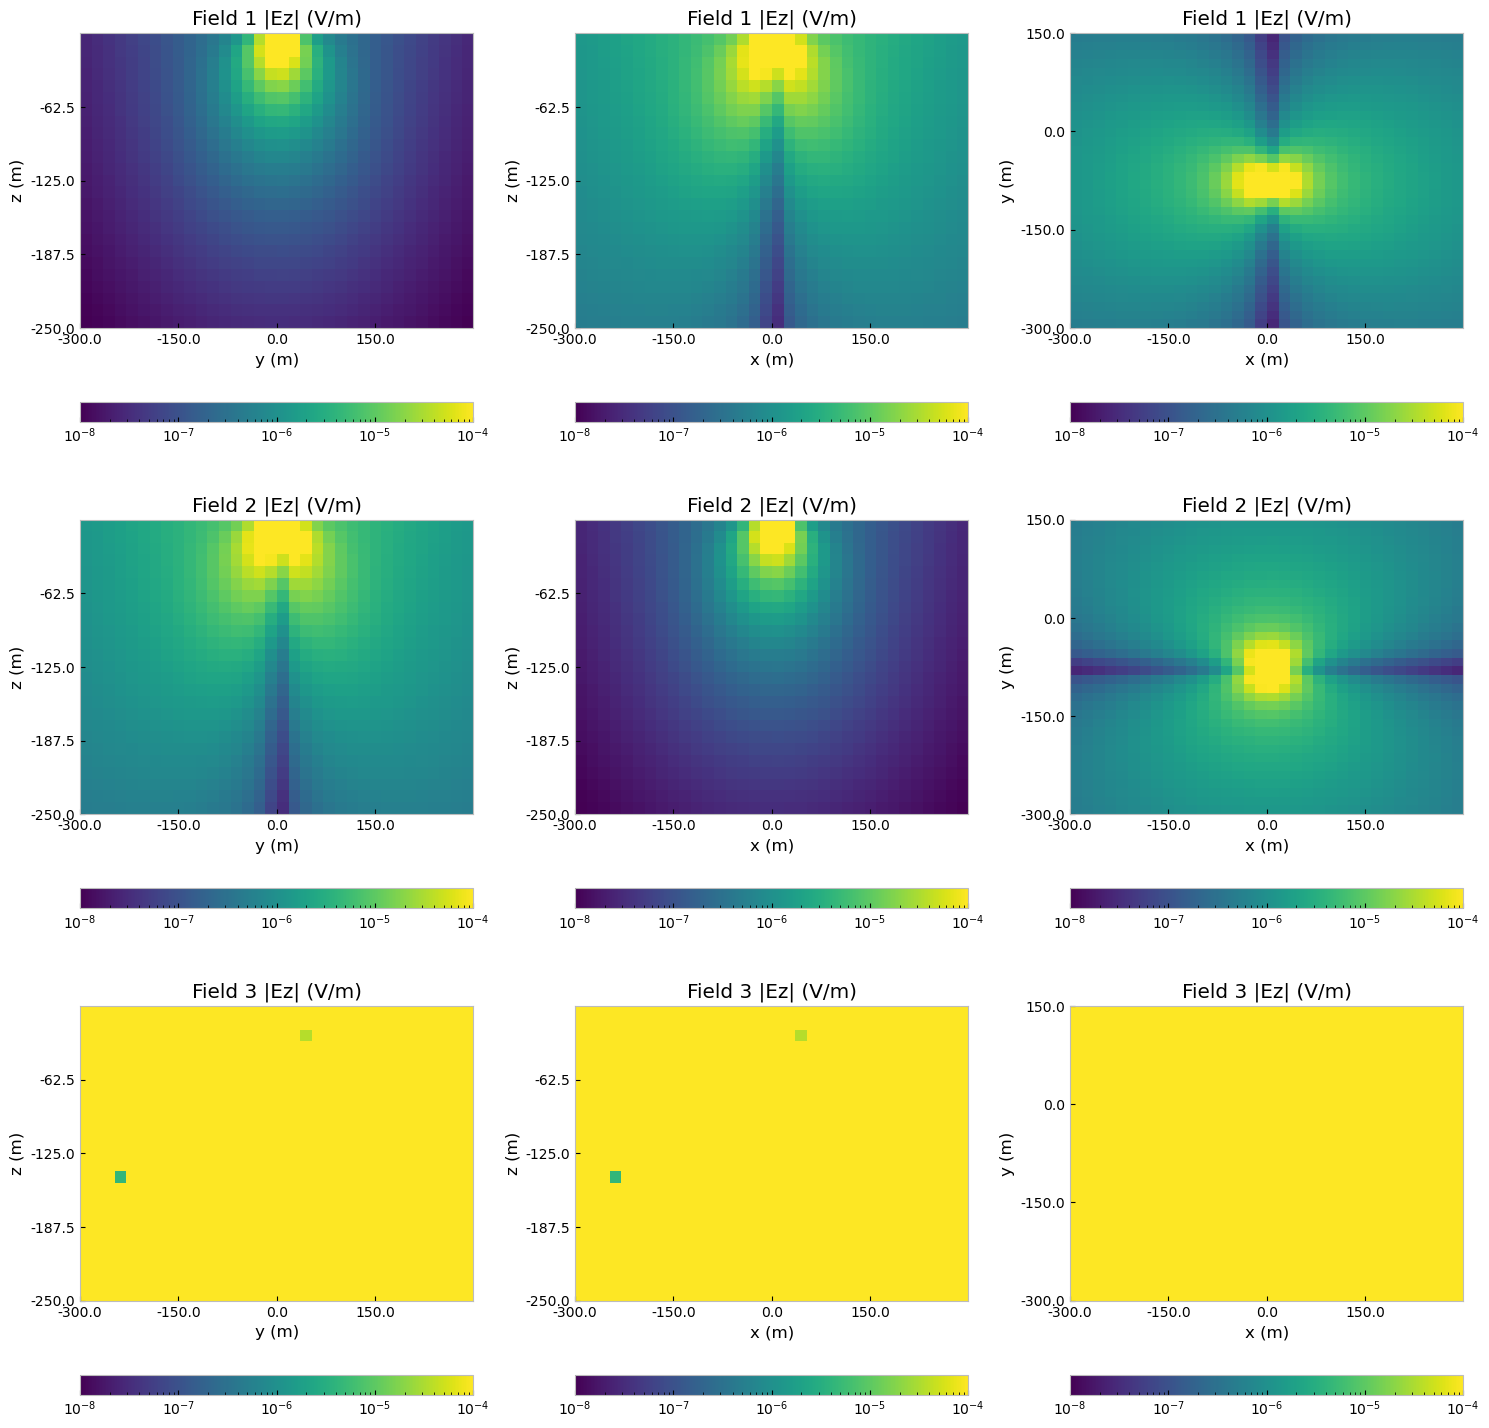

In [143]:
#Plotting solutions

ifr = 1

efield1 = anom_solutions[keys[ifr*3]]
print('Field 1: '+keys[ifr*3])
efield2 = anom_solutions[keys[ifr*3+1]]
print('Field 2: '+keys[ifr*3+1])
efield3 = anom_solutions[keys[ifr*3+2]]
print('Field 3: '+keys[ifr*3+2])

manual_xyz_slice_9x(efield1, efield2, efield3, ix = 17, iy = 17, iz = 1, xmin=-300, xmax=300, ymin=-300, ymax=300, zmin=-250, zmax=0, vmin = 1e-8, vmax = 1e-4)

#manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-6, vmax = 1e1)

## Different anomalies

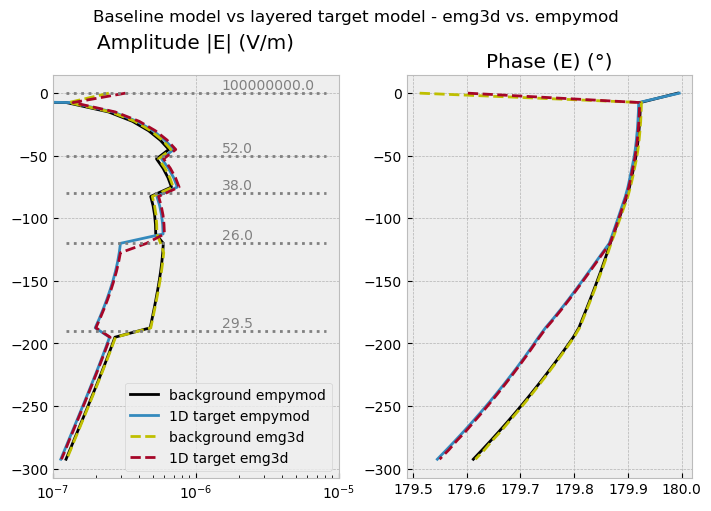

In [236]:
# Plot it
fig3, (ax31, ax32) = plt.subplots(1, 2, figsize=(7, 5), constrained_layout=True)

fig3.suptitle("Baseline model vs layered target model - emg3d vs. empymod")

ax31.set_title('Amplitude |E| (V/m)')
ax31.plot(resp_E_base.amp(), -offsets, 'k', label='background empymod')
ax31.plot(resp_E_target1.amp(), -offsets, 'C0-', label='1D target empymod')
ax31.plot(resp_E_base_3D.amp(), -offsets, 'y--', label='background emg3d') # scale your emg3d amplitues by the source length
ax31.plot(resp_E_target1_3D.amp(), -offsets, 'C1--', label='1D target emg3d') # scale your emg3d amplitues by the source length
ax31.set_xscale('log')
ax31.set_xlim([1e-7, 1e-5])
ax31.legend()

ax32.set_title('Phase (E) (°)')
ax32.plot(resp_E_base.pha(deg=True), -offsets, 'k')
ax32.plot(resp_E_target1.pha(deg=True), -offsets, 'C0-')
ax32.plot(resp_E_base_3D.pha(deg=True), -offsets, 'y--')
ax32.plot(resp_E_target1_3D.pha(deg=True), -offsets, 'C1--')

ax33 = ax31.twiny()
#ax33.set_title('Model rho (Ohmm)')
#ax33.plot([75, 52.0, 52.0, 38.0, 38.0, 26.0, 26.0, 29.5, 29.5, 17.5, 17.5], [0, 0, -50, -50, -80, -80, -120, -120, -190, -190, -300], 'gray', ls='-')
ax33.hlines(depth, 0, 1, color='gray', ls=':', zorder=-1)
for i in np.arange(len(depth)):
    ax33.text(0.6, depth[i]+3, str(resistivities_base[i]), color='gray')
ax33.set_axis_off()

[0, -300, -250] [0, 300, 0]
x position:  -1.759303813742008e-11
y_bounds:  -299.99999999999443  ,  290.00000000000557
z_bounds:  -247.49999999999577  ,  -2.499999999995765
[0, -300, -250] [0, 300, 0]
x position:  -1.759303813742008e-11
y_bounds:  -299.99999999999443  ,  290.00000000000557
z_bounds:  -247.49999999999577  ,  -2.499999999995765


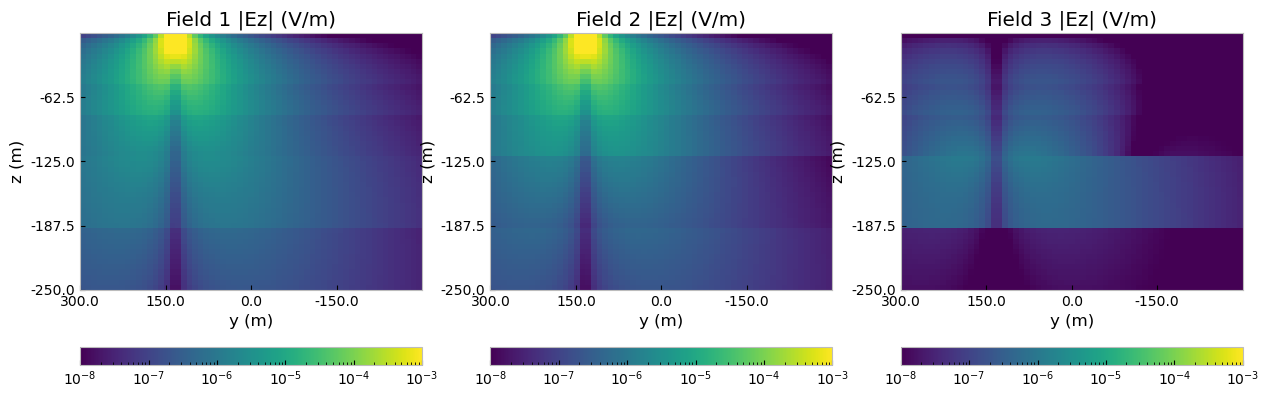

In [308]:
#Layered plume model

efield1 = crop_to_domain(efield3D_base, grid, x_slice = 0, y_extent=300, zmin=-250, zmax=0)
efield2 = crop_to_domain(efield3D_target1, grid, x_slice = 0, y_extent=300, zmin=-250, zmax=0)
efield3 = np.abs(efield2)-np.abs(efield1)

manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-8, vmax = 1e-3)

In [ ]:
emg3d.Report()